## Codigo para pruebas de multiples plies en un unico encoder

In [1]:
import chess
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import chess.pgn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from tqdm.notebook import tqdm
from scipy.stats import spearmanr
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import random

import joblib

SEED = 37
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

tf.keras.utils.set_random_seed(SEED)

plt.ion()

I0000 00:00:1788804670.877521     961 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788804673.559049     961 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
def fen_to_bitboard_vector_13(fen):
    """Convierte una notación FEN a un vector binario de 832 bits (13 x 64), incluyendo un bitboard de casillas vacías."""
    board = chess.Board(fen)

    piece_types = [
        (chess.PAWN, chess.WHITE), (chess.PAWN, chess.BLACK),
        (chess.ROOK, chess.WHITE), (chess.ROOK, chess.BLACK),
        (chess.KNIGHT, chess.WHITE), (chess.KNIGHT, chess.BLACK),
        (chess.BISHOP, chess.WHITE), (chess.BISHOP, chess.BLACK),
        (chess.QUEEN, chess.WHITE), (chess.QUEEN, chess.BLACK),
        (chess.KING, chess.WHITE), (chess.KING, chess.BLACK),
    ]

    vec = np.zeros(13 * 64, dtype=np.uint8)

    # Llenamos los 12 primeros bitboards
    for i, (piece, color) in enumerate(piece_types):
        bitboard = board.pieces(piece, color)
        for square in bitboard:
            vec[i * 64 + square] = 1

    # Bitboard 13: casillas vacías
    occupied = board.occupied
    for square in chess.SQUARES:
        if not occupied & chess.BB_SQUARES[square]:
            vec[12 * 64 + square] = 1

    return vec

In [3]:
def get_positions_at_plies(pgn_filename, ply_numbers=[15,16,17,18, 20,21,22,23, 30,31,32,33, 40,41,42,43,44], max_games=None):
    """Devuelve las posiciones después de los plies indicados."""
    positions = []
    elos = []
    times = []
    with open(pgn_filename, "r", encoding="utf-8") as f:
        pbar = tqdm(total=max_games, desc="Procesando partidas")
        while True:
            game = chess.pgn.read_game(f)
            if game is None:
                break
            pbar.update(1)
            if max_games and pbar.n > max_games:
                break
            board = game.board()
            secuencia = []
            for i, move in enumerate(game.mainline_moves()):
                board.push(move)
                ply = i + 1
                if ply in ply_numbers:
                    secuencia.append(
                        fen_to_bitboard_vector_13(board.fen()) #aca decido si uso 12 o 13
                    )
                if ply >= max(ply_numbers):
                    break
            # Solo guardar partidas que tengan todos los plies solicitados
            if len(secuencia) == len(ply_numbers):
                positions.append(secuencia)
                elos.append(
                    min(
                        int(game.headers.get("WhiteElo", 0)),
                        int(game.headers.get("BlackElo", 0))
                    )
                )
                times.append(
                    int(game.headers.get("TimeControl", "").split("+")[0])
                )
        pbar.close()
    return np.array(positions), np.array(elos), np.array(times)

In [2]:
# Parámetros
archivo_train = "../data/lichess_elite_2024-06.pgn"
archivo_test = "../data/2018_sin_limites"
n = 100000
archivo_salida_15 = "../data/generado/mezcla/train_ply15a18.npy"
archivo_salida_20 = "../data/generado/mezcla/train_ply20a23.npy"
archivo_salida_30 = "../data/generado/mezcla/train_ply30a33.npy"
archivo_salida_40 = "../data/generado/mezcla/train_ply40a43.npy"
archivo_salida_test_15 = "../data/generado/mezcla/test_ply15a18.npy"
archivo_salida_test_20 = "../data/generado/mezcla/test_ply20a23.npy"
archivo_salida_test_30 = "../data/generado/mezcla/test_ply30a33.npy"
archivo_salida_test_40 = "../data/generado/mezcla/test_ply40a43.npy"
archivo_salida_elos = "../data/generado/mezcla/elos.npy"
archivo_salida_times = "../data/generado/mezcla/tiempos.npy"
plies=[15,16,17,18, 20,21,22,23, 30,31,32,33, 40,41,42,43,44]

In [5]:
# Correr para obtener la data de train
positions,_,_ = get_positions_at_plies(archivo_train,ply_numbers=plies, max_games = n)

print(f"obtenidas {len(positions)} posiciones.")


Procesando partidas:   0%|          | 0/100000 [00:00<?, ?it/s]

obtenidas 89812 posiciones.


In [6]:
np.save(archivo_salida_15,positions[:, 0:0+4, :])
np.save(archivo_salida_20,positions[:, 4:4+4, :])
np.save(archivo_salida_30,positions[:, 8:8+4, :])
np.save(archivo_salida_40,positions[:, 12:12+4, :])

In [7]:
# Correr para obtener por primera vez los datos para el test
ply_test_positions, test_elo, test_times = get_positions_at_plies(archivo_test, ply_numbers=plies,max_games = 50000)

np.save(archivo_salida_test_15,ply_test_positions[:, 0:0+4, :])
np.save(archivo_salida_test_20,ply_test_positions[:, 4:4+4, :])
np.save(archivo_salida_test_30,ply_test_positions[:, 8:8+4, :])
np.save(archivo_salida_test_40,ply_test_positions[:, 12:12+4, :])

np.save(archivo_salida_elos, test_elo)
np.save(archivo_salida_times, test_times)

Procesando partidas:   0%|          | 0/50000 [00:00<?, ?it/s]

In [3]:
encoding_dim = 75

encoder_salida = f"../data/encoders/mezcla/mezclaPlies_basic_LE{encoding_dim}.npy"
archivo_salida_loss = f"../data/losses/mezcla/mezclaPlies_basic_LE{encoding_dim}.npy"

In [4]:
# division de datos 
positions = np.load(f"../data/generado/mezcla/train_ply15203040.npy").astype("float32")
train_positions, val_positions = train_test_split(positions, test_size=0.15, random_state=SEED)
del positions
print(f"Train size: {train_positions.shape} | Val size: {val_positions.shape}")


Train size: (76340, 4, 832) | Val size: (13472, 4, 832)


In [5]:
# flatten para el basic
train_positions = train_positions.reshape(train_positions.shape[0], -1)
val_positions = val_positions.reshape(val_positions.shape[0], -1)
print(f"Train size: {train_positions.shape} | Val size: {val_positions.shape}")

Train size: (76340, 3328) | Val size: (13472, 3328)


In [6]:
# === DEFINICIÓN DEL AUTOENCODER BASIC===


input_layer = keras.Input(shape=(3328,))
encoded = keras.layers.Dense(1600, activation="relu")(input_layer)
encoded = keras.layers.Dense(960, activation="relu")(encoded)
encoded = keras.layers.Dense(576, activation="relu")(encoded)
encoded = keras.layers.Dense(345, activation="relu")(encoded)
encoded = keras.layers.Dense(200, activation="relu")(encoded)
encoded = keras.layers.Dense(125, activation="relu")(encoded)
latent = keras.layers.Dense(encoding_dim)(encoded)
decoded = keras.layers.Dense(125, activation="relu")(latent)
decoded = keras.layers.Dense(200, activation="relu")(decoded)
decoded = keras.layers.Dense(345, activation="relu")(decoded)
decoded = keras.layers.Dense(576, activation="relu")(decoded)
decoded = keras.layers.Dense(960, activation="relu")(decoded)
decoded = keras.layers.Dense(1600, activation="relu")(decoded)
output_layer = keras.layers.Dense(3328, activation="sigmoid")(decoded)

autoencoder = keras.Model(input_layer, output_layer)
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy",metrics=[
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ])

In [3]:
# === DEFINICIÓN DEL AUTOENCODER TIMES===

input_layer = keras.Input(shape=(4,832,))
encoded = keras.layers.TimeDistributed(Sequential([
        keras.layers.Dense(500, activation="relu"),
        keras.layers.Dense(300, activation="relu"),
        keras.layers.Dense(180, activation="relu"),
        keras.layers.Dense(110, activation="relu"),])
    )(input_layer) # sale 110*4
encoded = keras.layers.Flatten()(encoded)
encoded = keras.layers.Dense(264, activation="relu")(encoded)
encoded = keras.layers.Dense(160, activation="relu")(encoded)
latent = keras.layers.Dense(encoding_dim)(encoded)
decoded = keras.layers.Dense(160, activation="relu")(latent)
decoded = keras.layers.Dense(264, activation="relu")(decoded)
decoded = keras.layers.Dense(440, activation="relu")(decoded)
decoded = keras.layers.Reshape((4, 110))(decoded)
output_layer = keras.layers.TimeDistributed(
    Sequential([
        keras.layers.Dense(110, activation="relu"),
        keras.layers.Dense(180, activation="relu"),
        keras.layers.Dense(300, activation="relu"),
        keras.layers.Dense(500, activation="relu"),
        keras.layers.Dense(832, activation="sigmoid")])
    )(decoded)
autoencoder = keras.Model(input_layer, output_layer)

autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy",metrics=[
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ])

NameError: name 'encoding_dim' is not defined

In [7]:
# entrenamiento
history = autoencoder.fit(
    train_positions,
    train_positions,
    validation_data=(val_positions, val_positions),
    epochs=50,
    batch_size=64,
    shuffle=True,
    callbacks=[
        keras.callbacks.EarlyStopping( # frena si deja de mejorar
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]
)
joblib.dump(autoencoder, encoder_salida) #guardar el encoder


Epoch 1/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 63s 31ms/step - acc: 0.9543 - loss: 0.1082 - precision: 0.7179 - recall: 0.6680 - val_acc: 0.9614 - val_loss: 0.0941 - val_precision: 0.7653 - val_recall: 0.7180
Epoch 2/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - acc: 0.9649 - loss: 0.0863 - precision: 0.7887 - recall: 0.7433 - val_acc: 0.9665 - val_loss: 0.0826 - val_precision: 0.7978 - val_recall: 0.7569
Epoch 3/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - acc: 0.9672 - loss: 0.0810 - precision: 0.8028 - recall: 0.7606 - val_acc: 0.9677 - val_loss: 0.0801 - val_precision: 0.8046 - val_recall: 0.7659
Epoch 4/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - acc: 0.9686 - loss: 0.0778 - precision: 0.8114 - recall: 0.7714 - val_acc: 0.9693 - val_loss: 0.0766 - val_precision: 0.8150 - val_recall: 0.7767
Epoch 5/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - acc: 0.9698 - loss: 0.0752 - precision: 0.8183 - recall: 0.7804 - val_acc: 0.9700 - val_loss: 0.0750 - val_precision: 0.8196 - val_rec

['../data/encoders/mezcla/mezclaPlies_basic_LE75.npy']

In [8]:
del train_positions
del val_positions

In [17]:
#ply = 12 # 0 = 15, 4 = 20, 8 = 30, 12 = 40
encoding_dim = 275
encoder_salida = f"../data/encoders/mezcla/mezclaPlies_basic_LE{encoding_dim}.npy"
archivo_salida_loss = f"../data/losses/mezcla/mezclaPlies_basic_LE{encoding_dim}.npy"



In [9]:
# cargo encoders y datos de test
autoencoder = joblib.load(encoder_salida) # cargo el encoder
test_positions = np.load(f"../data/generado/mezcla/test_ply15203040.npy").astype("float32")


In [10]:
# correccion para basic
test_positions = test_positions.reshape(test_positions.shape[0], -1)

In [11]:
test_elo = np.load(archivo_salida_elos).astype("float32")
#test_times = np.load(archivo_salida_times).astype("float32")

In [12]:
predictions = autoencoder.predict(test_positions)
#predictions = predictions.reshape(predictions.shape[0],-1)
#test_positions = test_positions.reshape(test_positions.shape[0], -1)

1238/1238 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step


In [13]:
losses = np.mean(-(test_positions * np.log(predictions + 1e-7) +
      (1 - test_positions) * np.log(1 - predictions + 1e-7)),
      axis=1
)
np.save(archivo_salida_loss, losses) # cambiar

In [14]:
losses = np.load(archivo_salida_loss)

In [15]:
rho, p = spearmanr(test_elo, losses)
print("Espacio latente:",encoding_dim )
print("Pearson:",np.corrcoef(test_elo, losses)[0, 1])
print("Spearman:",rho)
print("Promedio loss:",np.mean(losses))
print("Desvio loss:",np.std(losses))

Espacio latente: 75
Pearson: -0.2568006524155467
Spearman: -0.24684937131406126
Promedio loss: 0.083068505
Desvio loss: 0.015309386


In [16]:
del losses
del predictions
del test_positions
del test_elo
#del test_times

In [17]:
del autoencoder

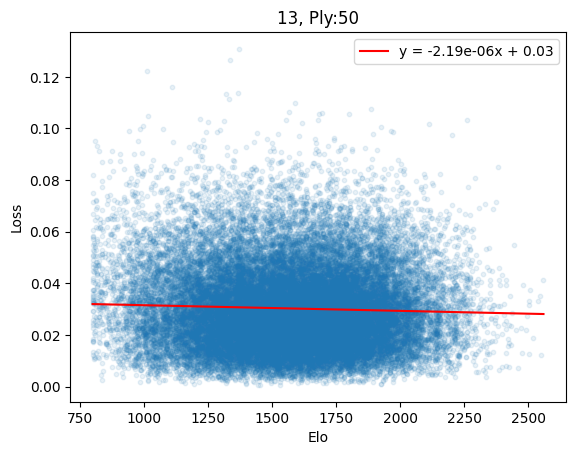

In [ ]:
plt.scatter(test_elo, losses, alpha=0.1, s=10)
yticks = np.arange(0, 0.18, 0.02)
# Ajuste lineal: grado 1 = línea recta (y = m*x + b)
m, b = np.polyfit(test_elo, losses, deg=1)

# Genero puntos de la recta para dibujarla prolija
x_recta = np.linspace(test_elo.min(), test_elo.max(), 100)
y_recta = m * x_recta + b

plt.plot(x_recta, y_recta, color="red", label=f"y = {m:.2e}x + {b:.2f}")
plt.title(f"13, Ply:{plies[ply]}")
plt.xlabel("Elo")
plt.ylabel("Loss")
plt.legend()
#plt.yticks(yticks)
#plt.ylim(0, 0.10)
plt.show()

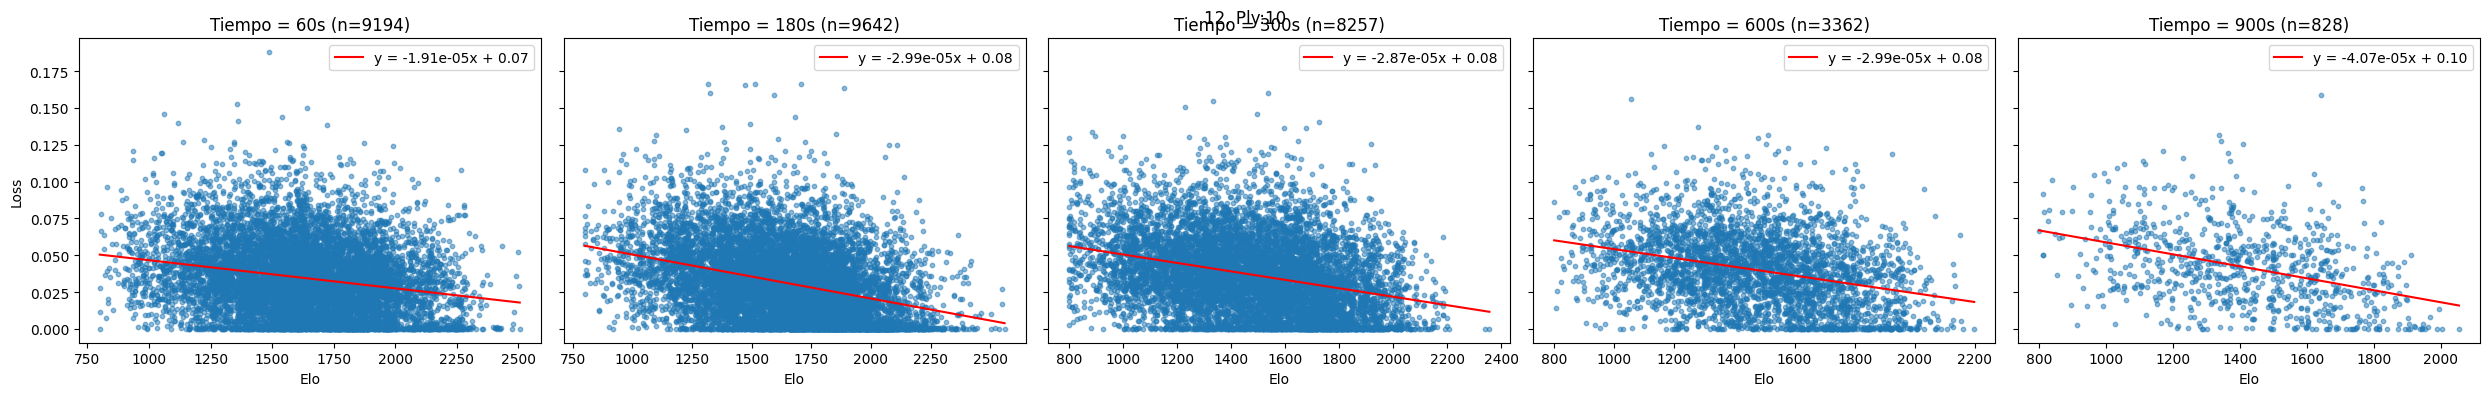

In [ ]:
tiempos_top = [60, 180, 300, 600, 900]
yticks = np.arange(0, 0.18, 0.02)

fig, axes = plt.subplots(1, len(tiempos_top), figsize=(5*len(tiempos_top), 4), sharey=True)

for ax, t in zip(axes, tiempos_top):
    mask = test_times == t

    # Ajuste lineal: grado 1 = línea recta (y = m*x + b)
    m, b = np.polyfit(test_elo[mask], losses[mask], deg=1)

    # Genero puntos de la recta para dibujarla prolija
    x_recta = np.linspace(test_elo[mask].min(), test_elo[mask].max(), 100)
    y_recta = m * x_recta + b
    ax.plot(x_recta, y_recta, color="red", label=f"y = {m:.2e}x + {b:.2f}")
    ax.scatter(test_elo[mask], losses[mask], alpha=0.5, s=10)
    ax.set_title(f"Tiempo = {t}s (n={mask.sum()})")
    ax.set_xlabel("Elo")
    ax.legend()
    #ax.set_yticks(yticks)
    #ax.set_ylim(0, 0.18)

axes[0].set_ylabel("Loss")
plt.tight_layout()
plt.suptitle(f"12, Ply:{plies[ply]}")
plt.show()

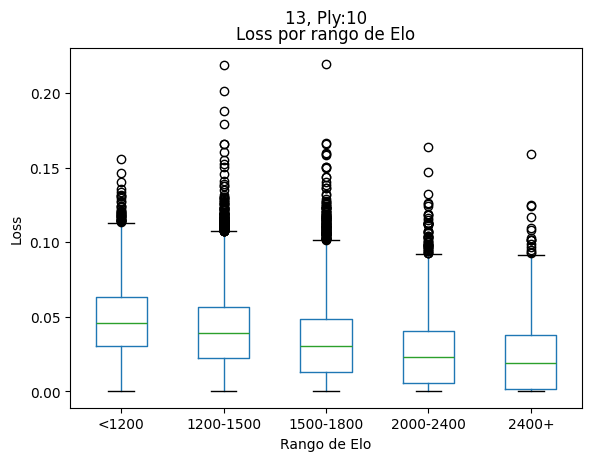

In [ ]:
df = pd.DataFrame({"elo": test_elo, "loss": losses})

# Definís los bordes de los bins vos mismo
yticks = np.arange(0, 0.18, 0.02)
bins = [0, 1200, 1500, 1800, 2000, 2400]
labels = ["<1200", "1200-1500", "1500-1800", "2000-2400", "2400+"]

df["elo_bin"] = pd.cut(df["elo"], bins=bins, labels=labels)

# Boxplot
df.boxplot(column="loss", by="elo_bin", grid=False)
plt.xlabel("Rango de Elo")
plt.ylabel("Loss")
plt.title("Loss por rango de Elo")

plt.suptitle(f"13, Ply:{plies[ply]}")
plt.show()

In [60]:
# cargar losses
LE = 75
loss_15 = np.load(f"../data/losses/mezcla/basic_ply15_LE{LE}.npy")
loss_20 = np.load(f"../data/losses/mezcla/basic_ply20_LE{LE}.npy")
loss_30 = np.load(f"../data/losses/mezcla/basic_ply30_LE{LE}.npy")
loss_40 = np.load(f"../data/losses/mezcla/basic_ply40_LE{LE}.npy")
test_elo = np.load(archivo_salida_elos).astype("float32")


In [61]:

z_15 = (loss_15 - np.mean(loss_15)) / np.std(loss_15)
z_20 = (loss_20 - np.mean(loss_20)) / np.std(loss_20)
z_30 = (loss_30 - np.mean(loss_30)) / np.std(loss_30)
z_40 = (loss_40 - np.mean(loss_40)) / np.std(loss_40)

z= [z_15, z_20, z_30, z_40]

max_loss = np.maximum.reduce(z)

mean_loss = np.mean(z, axis=0)


In [62]:
print("Max loss:")
rho, p = spearmanr(test_elo, max_loss)
print("Correlacion: ",np.corrcoef(test_elo, max_loss)[0, 1])
print("Spearman: ",rho, p)
print("Promedio:",np.mean(max_loss))
print("Desvio: ",np.std(max_loss))

Max loss:
Correlacion:  -0.1780018934762224
Spearman:  -0.17320383460436417 3.320154351805801e-264
Promedio: 0.7385283
Desvio:  0.9436613


In [63]:
print("Mean loss:")
rho, p = spearmanr(test_elo, mean_loss)
print("Correlacion: ",np.corrcoef(test_elo, mean_loss)[0, 1])
print("Spearman: ",rho, p)
print("Promedio:",np.mean(mean_loss))
print("Desvio: ",np.std(mean_loss))

Mean loss:
Correlacion:  -0.2436278750124055
Spearman:  -0.23134289443820685 0.0
Promedio: 1.059879e-07
Desvio:  0.7828082


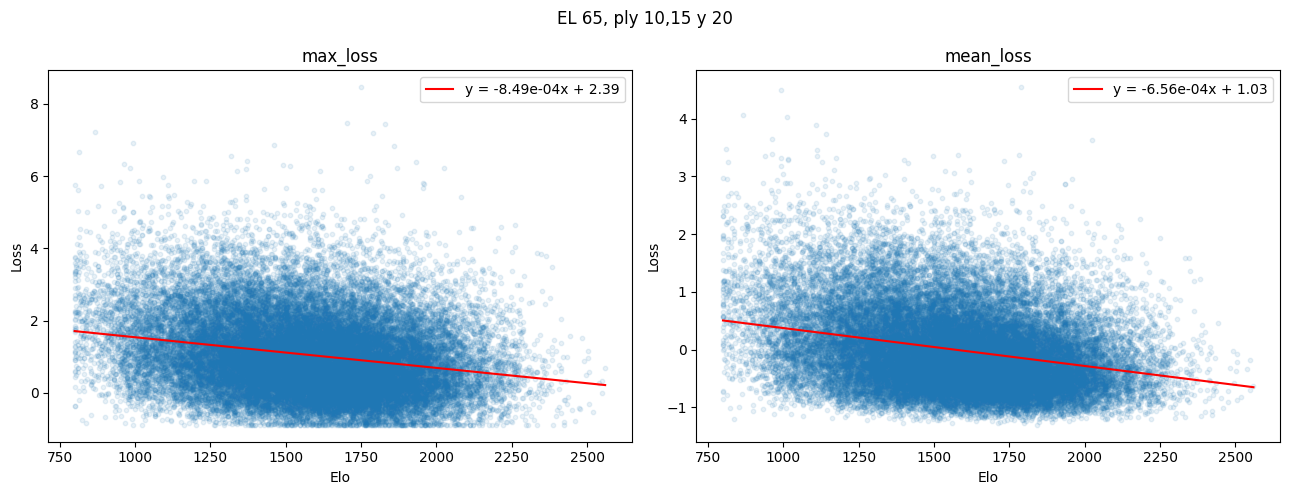

In [ ]:
# Variables a graficar
losses = [
    max_loss,
    mean_loss,
]
titulos = [
    "max_loss",
    "mean_loss",
]
ylabels = [
    "max_standarized_loss",
    "mean_standarized_loss",
]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, loss, titulo, ylabel in zip(axes.flat, losses, titulos,ylabels):
    # Scatter
    ax.scatter(test_elo[:50000], loss[:50000], alpha=0.1, s=10)
    # Ajuste lineal
    m, b = np.polyfit(test_elo[:50000], loss[:50000], deg=1)
    # Puntos de la recta
    x_recta = np.linspace(test_elo.min(), test_elo.max(), 100)
    y_recta = m * x_recta + b
    # Recta
    ax.plot(
        x_recta,
        y_recta,
        color="red",
        label=f"y = {m:.2e}x + {b:.2f}"
    )
    ax.set_title(titulo)
    ax.set_xlabel("Elo")
    ax.set_ylabel("Loss")
    ax.legend()
plt.suptitle("EL 65, ply 10,15 y 20")
plt.tight_layout()
plt.show()

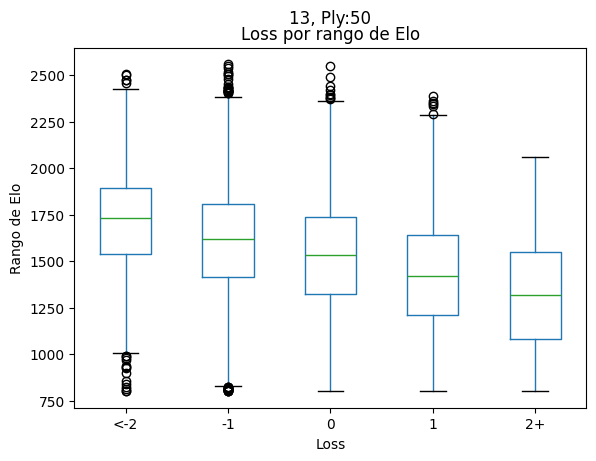

In [ ]:
df = pd.DataFrame({"elo":mean_loss , "loss": test_elo})

# Definís los bordes de los bins vos mismo
yticks = np.arange(0, 0.18, 0.02)
bins = [-2, -1, 0, 1, 2, 3]
labels = ["<-2", "-1", "0", "1", "2+"]

df["elo_bin"] = pd.cut(df["elo"], bins=bins, labels=labels)

# Boxplot
df.boxplot(column="loss", by="elo_bin", grid=False)
plt.ylabel("Rango de Elo")
plt.xlabel("Loss")
plt.title("Loss por rango de Elo")

plt.suptitle(f"13, Ply:{plies[ply]}")
plt.show()